In [12]:
import json
import statistics
import pprint
import math

import matplotlib.pyplot as plt
from persiantools.digits import en_to_fa
import arabic_reshaper
from bidi.algorithm import get_display
import numpy as np

In [13]:
BASE_PATH = ".."
TOTAL_RUNS = 30
MODULE = "sensor"
BRANCHES = {"algo", "base", "wholesuite"}

runs_info = {}
for branch in BRANCHES:
    runs = [[] for i in range(TOTAL_RUNS)]
    for i in range(TOTAL_RUNS):
        with open(f"{BASE_PATH}/results/refined/{branch}_{MODULE}_{i+1}", 'r', encoding='utf-8') as f:
            for line in f:
                runs[i].append(json.loads(line))
        print(f"Processed {branch}_{MODULE}_{i}")
    runs_info[branch] = runs
print('Done')

Processed algo_sensor_0
Processed algo_sensor_1
Processed algo_sensor_2
Processed algo_sensor_3
Processed algo_sensor_4
Processed algo_sensor_5
Processed algo_sensor_6
Processed algo_sensor_7
Processed algo_sensor_8
Processed algo_sensor_9
Processed algo_sensor_10
Processed algo_sensor_11
Processed algo_sensor_12
Processed algo_sensor_13
Processed algo_sensor_14
Processed algo_sensor_15
Processed algo_sensor_16
Processed algo_sensor_17
Processed algo_sensor_18
Processed algo_sensor_19
Processed algo_sensor_20
Processed algo_sensor_21
Processed algo_sensor_22
Processed algo_sensor_23
Processed algo_sensor_24
Processed algo_sensor_25
Processed algo_sensor_26
Processed algo_sensor_27
Processed algo_sensor_28
Processed algo_sensor_29
Processed base_sensor_0
Processed base_sensor_1
Processed base_sensor_2
Processed base_sensor_3
Processed base_sensor_4
Processed base_sensor_5
Processed base_sensor_6
Processed base_sensor_7
Processed base_sensor_8
Processed base_sensor_9
Processed base_senso

In [14]:
results = {}
for branch in BRANCHES:
    coverages = []
    mean_sol_et = []
    mean_sol_mu = []
    mean_pop_et = []
    mean_pop_mu = []

    runs = runs_info[branch]
    min_elapsed_time = min(min(e['elapsed_time'] for e in run) for i, run in enumerate(runs))
    max_elapsed_time = max(max(e['elapsed_time'] for e in run) for i, run in enumerate(runs))    
    runs_index: list[int] = [0 for _ in runs]
    for t in np.arange(min_elapsed_time, max_elapsed_time, 1):
        for i, run in enumerate(runs):
            while True:
                idx = runs_index[i]
                if idx+1 == len(run) or run[idx+1]['elapsed_time'] > t:
                    break
                runs_index[i] += 1

        coverages.append({
            't': t,
            'cov': statistics.mean(run[runs_index[i]]['solutions']['cov'] for i, run in enumerate(runs))
        })
        mean_sol_et.append({
            't': t,
            'et': statistics.mean(run[runs_index[i]]['solutions']['et']['mean'] for i, run in enumerate(runs))
        })
        mean_sol_mu.append({
            't': t,
            'mu': statistics.mean(run[runs_index[i]]['solutions']['mu']['mean'] for i, run in enumerate(runs))
        })
        mean_pop_et.append({
            't': t,
            'et': statistics.mean(run[runs_index[i]]['population']['et']['mean'] for i, run in enumerate(runs))
        })
        mean_pop_mu.append({
            't': t,
            'mu': statistics.mean(run[runs_index[i]]['population']['mu']['mean'] for i, run in enumerate(runs))
        })
    results[f'{branch}_cov'] = coverages
    results[f'{branch}_sol_et'] = mean_sol_et
    results[f'{branch}_sol_mu'] = mean_sol_mu
    results[f'{branch}_pop_et'] = mean_pop_et
    results[f'{branch}_pop_mu'] = mean_pop_mu
print('Done')

Done


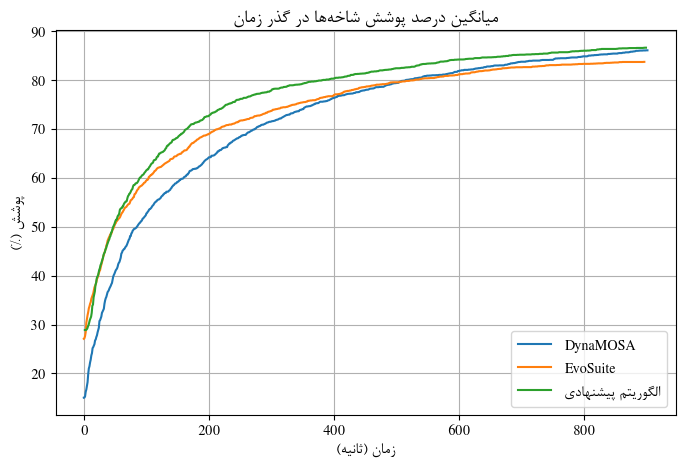

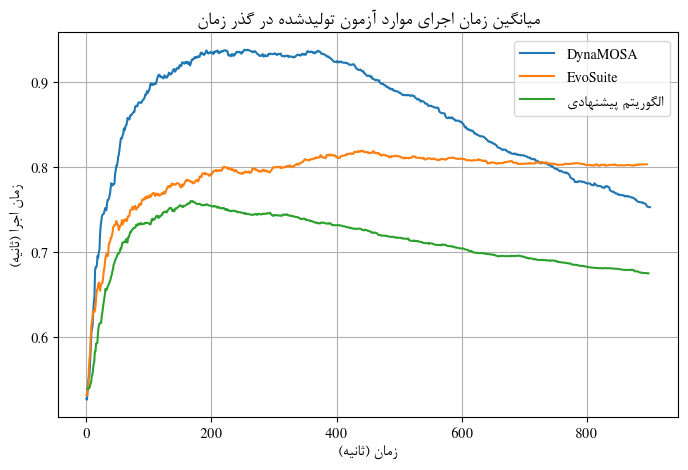

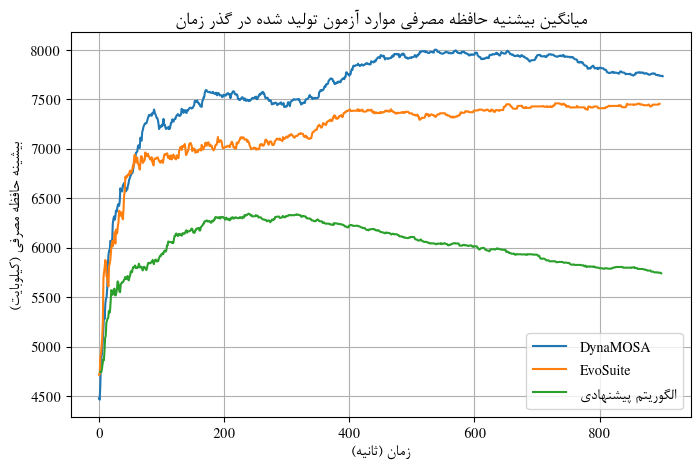

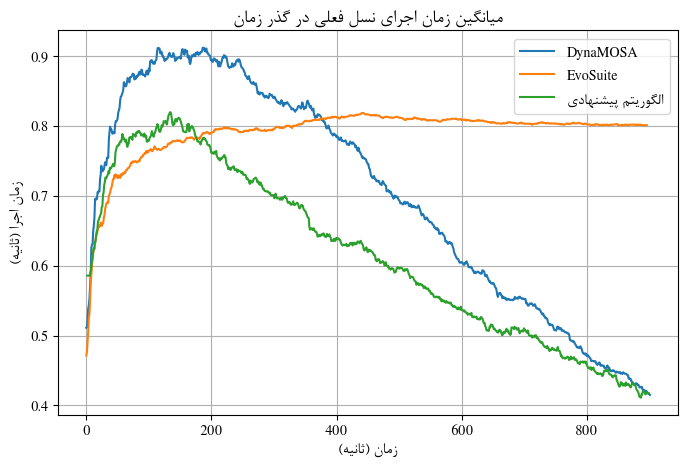

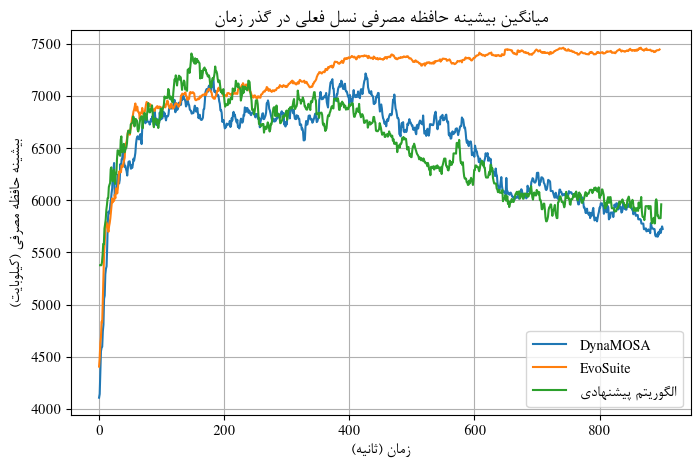

In [15]:
plt.rcParams["font.family"] = ["Nazli"] # Titr or Nazli
plt.rcParams["font.size"] = 12
plt.rcParams["axes.unicode_minus"] = False  # Fix negative sign issues

def persian_text(text):
    reshaped_text = arabic_reshaper.reshape(text)
    bidi_text = get_display(reshaped_text)
    return bidi_text

# Create plot
# x_labels = [0, 1, 2, 3]
# x_labels_persian = [en_to_fa(str(x)) for x in x_labels]  # Convert to Persian digits
# plt.xticks(x_labels, x_labels_persian)

plt.figure(figsize=(8, 5))
plt.title(persian_text("میانگین درصد پوشش شاخه‌ها در گذر زمان"))
plt.plot([e['t'] for e in results['base_cov']], [e['cov']*100 for e in results['base_cov']], label='DynaMOSA')
plt.plot([e['t'] for e in results['wholesuite_cov']], [e['cov']*100 for e in results['wholesuite_cov']], label='EvoSuite')
plt.plot([e['t'] for e in results['algo_cov']], [e['cov']*100 for e in results['algo_cov']], label=persian_text('الگوریتم پیشنهادی'))
plt.xlabel(persian_text("زمان (ثانیه)"))
plt.ylabel(persian_text("پوشش (٪)"))
plt.grid(True)
plt.legend()
plt.savefig(f"{BASE_PATH}/results/plots/{MODULE}_cov.jpeg")
plt.show()

plt.figure(figsize=(8, 5))
plt.title(persian_text("میانگین زمان اجرای موارد آزمون تولیدشده در گذر زمان"))
plt.plot([e['t'] for e in results['base_sol_et']], [e['et']/1e9 for e in results['base_sol_et']], label='DynaMOSA')
plt.plot([e['t'] for e in results['wholesuite_sol_et']], [e['et']/1e9 for e in results['wholesuite_sol_et']], label='EvoSuite')
plt.plot([e['t'] for e in results['algo_sol_et']], [e['et']/1e9 for e in results['algo_sol_et']], label=persian_text('الگوریتم پیشنهادی'))
plt.xlabel(persian_text("زمان (ثانیه)"))
plt.ylabel(persian_text("زمان اجرا (ثانیه)"))
plt.grid(True)
plt.legend()
plt.savefig(f"{BASE_PATH}/results/plots/{MODULE}_sol_et.jpeg")
plt.show()

plt.figure(figsize=(8, 5))
plt.title(persian_text("میانگین بیشنیه حافظه مصرفی موارد آزمون تولید شده در گذر زمان"))
plt.plot([e['t'] for e in results['base_sol_mu']], [e['mu']/1e3 for e in results['base_sol_mu']], label='DynaMOSA')
plt.plot([e['t'] for e in results['wholesuite_sol_mu']], [e['mu']/1e3 for e in results['wholesuite_sol_mu']], label='EvoSuite')
plt.plot([e['t'] for e in results['algo_sol_mu']], [e['mu']/1e3 for e in results['algo_sol_mu']], label=persian_text('الگوریتم پیشنهادی'))
plt.xlabel(persian_text("زمان (ثانیه)"))
plt.ylabel(persian_text("بیشینه حافظه مصرفی (کیلوبایت)"))
plt.grid(True)
plt.legend()
plt.savefig(f"{BASE_PATH}/results/plots/{MODULE}_sol_mu.jpeg")
plt.show()

plt.figure(figsize=(8, 5))
plt.title(persian_text("میانگین زمان اجرای نسل فعلی در گذر زمان"))
plt.plot([e['t'] for e in results['base_pop_et']], [e['et']/1e9 for e in results['base_pop_et']], label='DynaMOSA')
plt.plot([e['t'] for e in results['wholesuite_pop_et']], [e['et']/1e9 for e in results['wholesuite_pop_et']], label='EvoSuite')
plt.plot([e['t'] for e in results['algo_pop_et']], [e['et']/1e9 for e in results['algo_pop_et']], label=persian_text('الگوریتم پیشنهادی'))
plt.xlabel(persian_text("زمان (ثانیه)"))
plt.ylabel(persian_text("زمان اجرا (ثانیه)"))
plt.grid(True)
plt.legend()
plt.savefig(f"{BASE_PATH}/results/plots/{MODULE}_pop_et.jpeg")
plt.show()

plt.figure(figsize=(8, 5))
plt.title(persian_text("میانگین بیشینه حافظه مصرفی نسل فعلی در گذر زمان"))
plt.plot([e['t'] for e in results['base_pop_mu']], [e['mu']/1e3 for e in results['base_pop_mu']], label='DynaMOSA')
plt.plot([e['t'] for e in results['wholesuite_pop_mu']], [e['mu']/1e3 for e in results['wholesuite_pop_mu']], label='EvoSuite')
plt.plot([e['t'] for e in results['algo_pop_mu']], [e['mu']/1e3 for e in results['algo_pop_mu']], label=persian_text('الگوریتم پیشنهادی'))
plt.xlabel(persian_text("زمان (ثانیه)"))
plt.ylabel(persian_text("بیشینه حافظه مصرفی (کیلوبایت)"))
plt.grid(True)
plt.legend()
plt.savefig(f"{BASE_PATH}/results/plots/{MODULE}_pop_mu.jpeg")
plt.show()

In [16]:
from scipy.stats import mannwhitneyu

# NOTE: Seems working without removing outliers, but do if needed.
# for branch in BRANCHES:
#     q1, q3 = np.percentile(time_to_coverage[branch], [25, 75])
#     iqr = q3 - q1
#     lower_bound = q1 - 1.5 * iqr
#     upper_bound = q3 + 1.5 * iqr
#     print(f'len({branch}) before removing outliers: {len(time_to_coverage[branch])}')
#     time_to_coverage[branch] = [t for t in time_to_coverage[branch] if lower_bound <= t <= upper_bound]
#     print(f'len({branch}) after removing outliers: {len(time_to_coverage[branch])}')

# TODO: might be good to draw a plot for these too instead of reporting descrete numbers.
COVERAGE_TARGETS = [0.40, 0.45, 0.50, 0.55, 0.60, 0.65, 0.70, 0.75, 0.80, 0.85, 0.90, 0.95, 0.99]
test_info = {branch: {} for branch in BRANCHES}
time_to_coverage = {}
for ct in COVERAGE_TARGETS:
    time_to_coverage[ct] = {}
    doable = True
    for branch in BRANCHES:
        runs = runs_info[branch]
        time_to_coverage[ct][branch] = []
        for i, run in enumerate(runs):
            times = [e['elapsed_time'] for e in run if e['solutions']['cov'] > ct]
            time_to_coverage[ct]
            if times:
                ttc = times[0]
            else:
                if branch == 'algo':
                    # print(f"# Coverage Target: {ct*100:.0f}")
                    # print(f"Missing ttc for run {i} on branch {branch}")
                    # print()
                    doable = False
                    break
                ttc = 1200 if MODULE == "banking" else 900
            time_to_coverage[ct][branch].append(ttc)

    if not doable:
        continue

    for branch in BRANCHES - {'algo'}:
        # Do distributions have the same shape?
        # plt.figure(figsize=(8, 6))
        # plt.boxplot([time_to_coverage['algo'], time_to_coverage[branch]], tick_labels=[persian_text('الگوریتم پیشنهادی'), branch])
        # plt.ylabel('Time to Coverage (s)')
        # plt.title(f'Distribution of TTC: Algorithm vs. {branch}')
        # plt.show()

        statistic, p_value = mannwhitneyu(time_to_coverage[ct]['algo'], time_to_coverage[ct][branch], alternative='less')
        base_ttc = statistics.mean(time_to_coverage[ct][branch])
        algo_ttc = statistics.mean(time_to_coverage[ct]['algo'])
        test_info[branch][ct*100] = {'u-statistic': float(statistic), 'p-value': float(p_value), 'algo_ttc': algo_ttc, 'base_ttc': base_ttc}

for branch in BRANCHES-{'algo'}:
    print(f'\n# {branch}')
    for cov, info in test_info[branch].items():
        print(cov, info) 


# base
40.0 {'u-statistic': 124.0, 'p-value': 7.459020084077053e-07, 'algo_ttc': 28.332617902755736, 'base_ttc': 56.30341694355011}
45.0 {'u-statistic': 153.0, 'p-value': 5.837180181275805e-06, 'algo_ttc': 38.06496272881826, 'base_ttc': 78.98552925586701}
50.0 {'u-statistic': 162.0, 'p-value': 1.0663629593593407e-05, 'algo_ttc': 52.6505690574646, 'base_ttc': 109.03989194234212}
55.00000000000001 {'u-statistic': 170.0, 'p-value': 1.7961711556348405e-05, 'algo_ttc': 66.61299293041229, 'base_ttc': 136.05841931502025}
60.0 {'u-statistic': 178.0, 'p-value': 2.9852779217095773e-05, 'algo_ttc': 93.10691872437795, 'base_ttc': 178.85804887612662}
65.0 {'u-statistic': 186.0, 'p-value': 4.895855098399711e-05, 'algo_ttc': 122.37771632671357, 'base_ttc': 215.856343626976}
70.0 {'u-statistic': 183.0, 'p-value': 4.073242037303443e-05, 'algo_ttc': 171.88543011347454, 'base_ttc': 283.9342114607493}
75.0 {'u-statistic': 213.0, 'p-value': 0.00023568757210657915, 'algo_ttc': 242.7489028453827, 'base_ttc'

In [1]:
L_BRANCHES = ['algo', *(BRANCHES-{'algo'})]
for ct in [0.5, 0.55, 0.6, 0.65, 0.7]:
    print(ct, L_BRANCHES)
    for i in range(0, TOTAL_RUNS, 2):
        for j, branch in enumerate(L_BRANCHES):
            print(f"{time_to_coverage[ct][branch][i]:.0f} & {time_to_coverage[ct][branch][i+1]:.0f}", end="")
            if j == len(BRANCHES) - 1:
                print(" \\\\")
            else:
                print(" & ", end="")
    print()

NameError: name 'BRANCHES' is not defined

# Archive

In [47]:
'hi'

'hi'